In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("26-customer_data.csv")

In [3]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


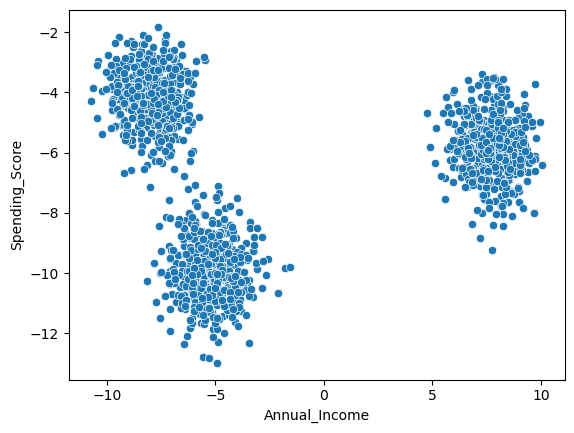

In [5]:
sns.scatterplot(df, x="Annual_Income", y="Spending_Score")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)
# k-means clusterleri yani labelleri ortaya çıkardıktan sonra(0,1,2) prediction yapmak için train test yapmak mantıklı, yoksa df ile de çalışabiliriiz.

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
scaler = MinMaxScaler()

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [16]:
# elbow method
wcss = []
for k in range (1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [15]:
kmeans.inertia_ # inertia bizim için wcss hesaplanmış hali

4.075621186331509

In [17]:
wcss

[196.9206878471016,
 68.44836482219307,
 11.697030239519943,
 9.895105565899934,
 7.884021543928317,
 6.089842499353227,
 5.54154781876689,
 4.988836079999139,
 4.693956743246922,
 4.405643019785732]

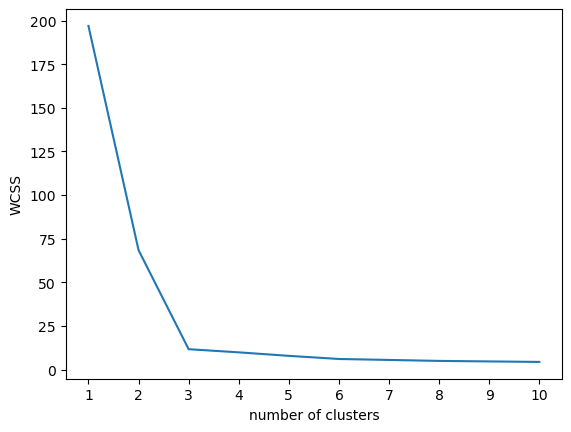

In [22]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()
#  kırılmanıj olduğu yer bizim ideal cluster sayımız yani 3

In [23]:
kmeans = KMeans(n_clusters=3)

In [24]:
kmeans.fit(X_test_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [25]:
y_pred = kmeans.predict(X_test_scaled)

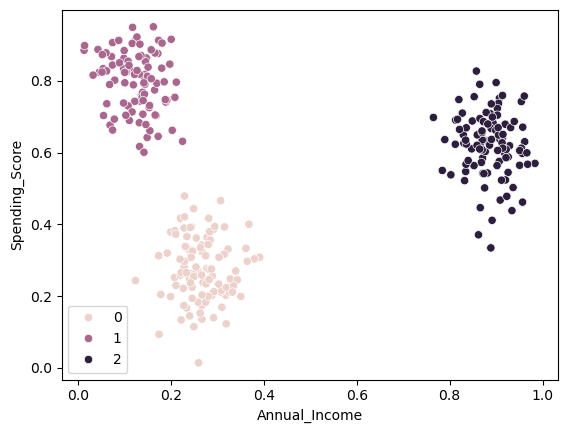

In [26]:
sns.scatterplot(data=pd.DataFrame(X_test_scaled, columns=X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

In [27]:
# CLUSTER BULMA YÖNTEMLERİ

In [28]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [29]:
from kneed import KneeLocator

In [30]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [31]:
kl.elbow

3

In [32]:
# silhoutte score

In [42]:
from sklearn.metrics import silhouette_score

In [43]:
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)

In [44]:
silhouette_scores

[0.6538372460771634,
 0.7856941696336582,
 0.6527412500645012,
 0.5375498724212413,
 0.5148947808259201,
 0.38200071658298507,
 0.3537612072103082,
 0.34235939954231964,
 0.33953516768847464]

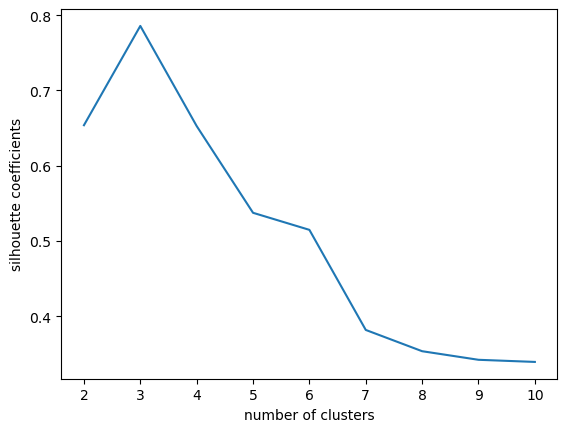

In [45]:
plt.plot(range(2,11), silhouette_scores)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficients")
plt.show()